## 1. Validating the Simulator

Before using Monte Carlo simulation for anything more interesting, I first confirm it's 
implemented correctly by checking that it converges to the Black-Scholes closed-form price 
as the number of simulated paths increases. Both methods price a European call under the 
same assumptions (constant volatility, geometric Brownian motion), so they should agree in 
the limit — if they don't, something is wrong with the simulation before I trust it for 
anything downstream.

In [1]:
import sys
sys.path.append('../src')
from pricing import black_scholes_price, monte_carlo_gbm_price
import numpy as np

S0, K, T, r, sigma = 100, 100, 1.0, 0.03, 0.20
print("Black-Scholes:", black_scholes_price(S0, K, T, r, sigma))
for n in [1_000, 10_000, 100_000, 1_000_000]:
    price, se = monte_carlo_gbm_price(S0, K, T, r, sigma, n_paths=n, seed=42)
    print(f"MC (n={n}): {price:.4f}, SE: {se:.4f}")

Black-Scholes: 9.413403383853016
MC (n=1000): 8.8811, SE: 0.4293
MC (n=10000): 9.3130, SE: 0.1416
MC (n=100000): 9.3875, SE: 0.0449
MC (n=1000000): 9.4161, SE: 0.0141


## 2. Pulling Real Market Data

Black-Scholes assumes constant volatility and normally distributed returns. Before building 
anything more sophisticated, I want to check whether that assumption actually holds for real 
data. I'm using ~10 years of daily SPY closing prices, converted to log returns.

In [2]:
import yfinance as yf
import pandas as pd

data = yf.download("SPY", start="2015-01-01", end="2025-01-01", progress = False)
data.to_csv("../data/spy.csv")

returns = np.log(data['Close'] / data['Close'].shift(1)).dropna()
returns = returns.squeeze()
returns.head()

Date
2015-01-05   -0.018225
2015-01-06   -0.009464
2015-01-07    0.012384
2015-01-08    0.017589
2015-01-09   -0.008046
Name: SPY, dtype: float64

In [3]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

In [4]:
print(data.shape)
returns.describe()

(2516, 5)


count    2515.000000
mean        0.000486
std         0.011137
min        -0.115887
25%        -0.003712
50%         0.000596
75%         0.005910
max         0.086731
Name: SPY, dtype: float64

## 3. Do Real Returns Actually Look Normal?

If Black-Scholes' assumptions held, SPY's daily returns should look approximately normally 
distributed, and volatility should stay roughly constant over time. I'm checking both: a 
QQ-plot against a normal distribution to look at the tails, and a rolling realized volatility 
plot to look for periods of calm vs. turbulence. If the tails curve away from the diagonal 
and volatility clusters into distinct regimes rather than staying flat, that's direct 
evidence against the constant-volatility assumption.

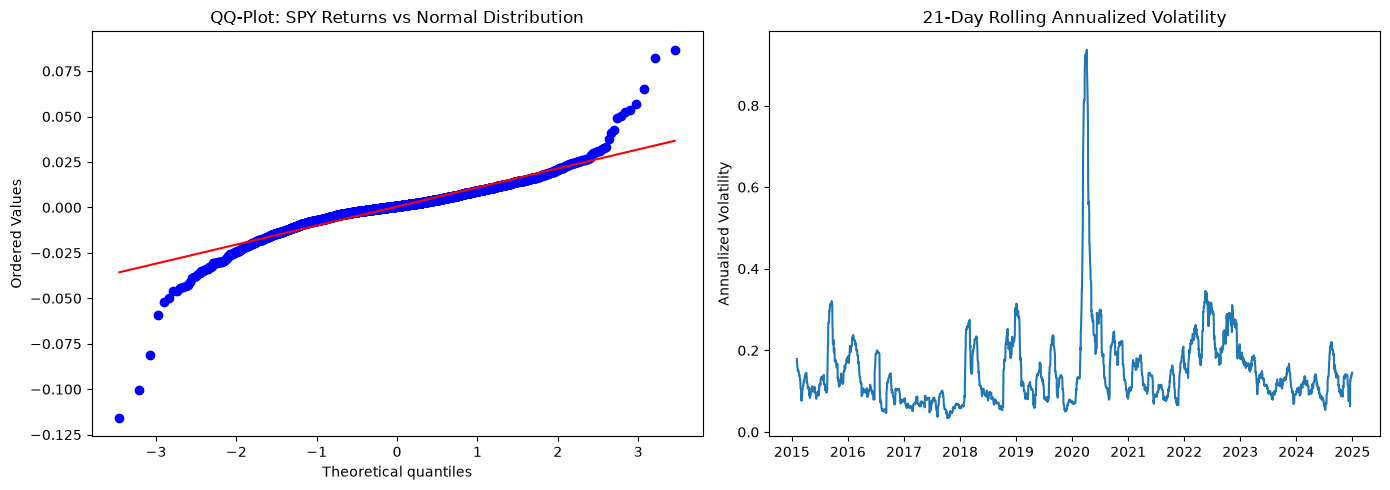

Excess kurtosis: 13.634388330474312


In [5]:
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: QQ-plot against a normal distribution
stats.probplot(returns, dist="norm", plot=axes[0])
axes[0].set_title("QQ-Plot: SPY Returns vs Normal Distribution")

# Right plot: rolling realized volatility (21-day window ~ 1 trading month)
rolling_vol = returns.rolling(21).std() * (252 ** 0.5)  # annualized
axes[1].plot(rolling_vol)
axes[1].set_title("21-Day Rolling Annualized Volatility")
axes[1].set_ylabel("Annualized Volatility")

plt.tight_layout()
plt.show()

print("Excess kurtosis:", stats.kurtosis(returns))

In [6]:
print(type(returns))
print(returns.shape)

<class 'pandas.Series'>
(2515,)


The QQ-plot shows visible curvature at both tails, and excess kurtosis of ~13.6 confirms 
this statistically — a normal distribution has 0 excess kurtosis, so SPY returns have 
dramatically fatter tails than Black-Scholes assumes. The rolling volatility plot also shows 
clear regime changes rather than a flat line, with a sharp spike visible during the 2020 
crash. Both findings motivate using a model that lets volatility vary over time instead of 
holding it constant.

## 4. Modeling Time-Varying Volatility with GARCH(1,1)

GARCH(1,1) models today's volatility as a function of yesterday's volatility and yesterday's 
squared return — letting volatility respond to recent market conditions instead of assuming 
it's fixed. I fit this via maximum likelihood estimation.

In [7]:
from arch import arch_model

# arch package expects returns in percentage points, not decimals
returns_pct = returns * 100

garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1, dist='normal')
garch_fit = garch_model.fit(disp='off')

print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3220.06
Distribution:                  Normal   AIC:                           6448.11
Method:            Maximum Likelihood   BIC:                           6471.43
                                        No. Observations:                 2515
Date:                Thu, Sep 10 2026   Df Residuals:                     2514
Time:                        13:19:15   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0867  1.469e-02      5.905  3.532e-09 [5.795e-0

`alpha[1] + beta[1] ≈ 0.97`, meaning volatility shocks are highly persistent — a turbulent 
day is likely to be followed by more turbulent days — but they decay over time rather than 
exploding, which is the expected, well-behaved pattern for a stable GARCH fit. Next, I check 
that the GARCH-implied volatility actually tracks realized volatility over time, as a 
sanity check that the model is capturing something real rather than just fitting noise.

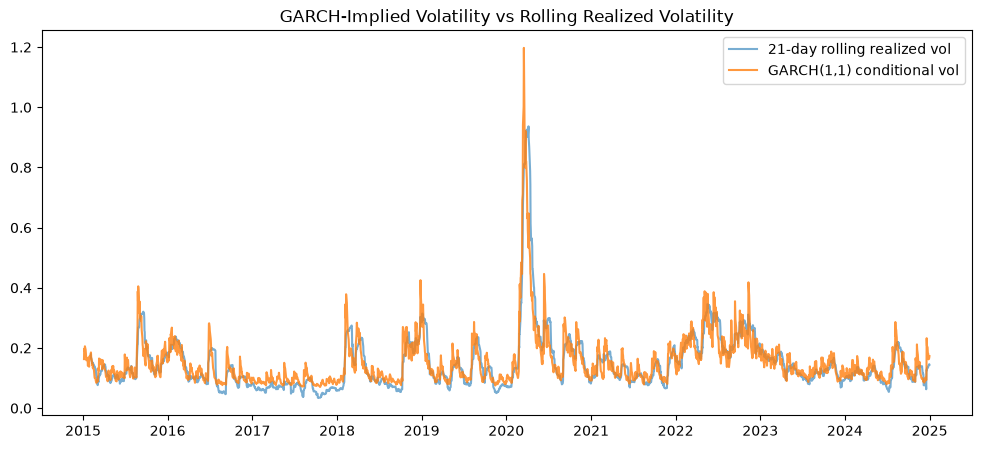

In [8]:
garch_vol = garch_fit.conditional_volatility / 100 * (252 ** 0.5)  # back to decimal, annualized

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rolling_vol, label='21-day rolling realized vol', alpha=0.6)
ax.plot(returns.index, garch_vol, label='GARCH(1,1) conditional vol', alpha=0.8)
ax.legend()
ax.set_title("GARCH-Implied Volatility vs Rolling Realized Volatility")
plt.show()

## 5. Quantifying the Mispricing

Now I compare option prices under two volatility inputs: a naive trailing-252-day historical 
volatility (a common simple approach) versus the current GARCH-implied volatility, which 
reacts faster to recent market conditions. Both are used to price the same 30-day 
at-the-money SPY call via Black-Scholes, isolating the effect of the volatility input alone.

In [9]:
# Most recent GARCH-implied volatility as "smart" vol estimate
current_garch_vol = garch_vol.iloc[-1]
if hasattr(current_garch_vol, 'item'):
    current_garch_vol = current_garch_vol.item()
    
# Naive historical volatility as the "naive" estimate
naive_vol = returns[-252:].std() * (252 ** 0.5)
if hasattr(naive_vol, 'item'):
    naive_vol = naive_vol.item()

S0_current = data['Close'].iloc[-1].item()
K = S0_current  # at-the-money option, simplest case
T = 30/365      # 30 days to maturity
r = 0.04        # risk-free rate assumption

price_naive = black_scholes_price(S0_current, K, T, r, naive_vol, "call")
price_garch = black_scholes_price(S0_current, K, T, r, current_garch_vol, "call")

print(f"Naive historical vol: {naive_vol:.4f}")
print(f"GARCH-implied vol:    {current_garch_vol:.4f}")
print(f"Price using naive vol: ${price_naive:.2f}")
print(f"Price using GARCH vol: ${price_garch:.2f}")
print(f"Difference: ${price_garch - price_naive:.2f} ({(price_garch/price_naive - 1)*100:.1f}%)")

Naive historical vol: 0.1258
GARCH-implied vol:    0.1730
Price using naive vol: $9.26
Price using GARCH vol: $12.35
Difference: $3.09 (33.4%)


## Conclusion

Using GARCH-implied volatility instead of naive historical volatility changes the price of 
a 30-day at-the-money SPY call by **33.4%** ($9.26 → $12.35). This gap reflects GARCH picking 
up on a recent uptick in volatility that the trailing-year historical average smooths over. 
In practice, this means naive historical-volatility pricing can meaningfully mismark options 
precisely when volatility is shifting — which is when getting it right matters most.